1) Importing Libraries

In [1]:
# Base Libraries
import matplotlib.pyplot as plt  
import numpy as np
import os
import pandas as pd
import seaborn as sns
# Transformation
from sklearn import preprocessing
# Models
from scipy.stats import skew
from scipy.stats import kurtosis
from sklearn import neighbors
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# Metrics
from sklearn.metrics import explained_variance_score
from sklearn.metrics import max_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score

2. Data preprocessing

In [2]:
# loading the dataset to a pandas dataframe
df = pd.read_csv('BigML_Dataset_5f50a4cc0d052e40e6000034.csv')

In [3]:
df["Is Daylight"] = df["Is Daylight"].astype(int)
df.info()

df = df.drop(columns = ["Day of Year"])
df = df.drop(columns = ["Month"])
df = df.drop(columns = ["Day"])
df = df.drop(columns = ["Visibility"])
df = df.drop(columns = ["Average Barometric Pressure (Period)"])

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Day of Year                           2920 non-null   int64  
 1   Year                                  2920 non-null   int64  
 2   Month                                 2920 non-null   int64  
 3   Day                                   2920 non-null   int64  
 4   First Hour of Period                  2920 non-null   int64  
 5   Is Daylight                           2920 non-null   int64  
 6   Distance to Solar Noon                2920 non-null   float64
 7   Average Temperature (Day)             2920 non-null   int64  
 8   Average Wind Direction (Day)          2920 non-null   int64  
 9   Average Wind Speed (Day)              2920 non-null   float64
 10  Sky Cover                             2920 non-null   int64  
 11  Visibility       

(2920, 11)

In [4]:
df.describe()

,Year,First Hour of Period,Is Daylight,Distance to Solar Noon,Average Temperature (Day),Average Wind Direction (Day),Average Wind Speed (Day),Sky Cover,Relative Humidity,Average Wind Speed (Period),Power Generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000
mean,2008.665753,11.500000,0.618151,0.503294,58.468493,24.953425,10.096986,1.987671,73.513699,10.129154,6979.846233
std,0.471807,6.875041,0.485923,0.298024,6.841200,6.915178,4.838185,1.411978,15.077139,7.261547,10312.336413
min,2008.000000,1.000000,0.000000,0.050401,42.000000,1.000000,1.100000,0.000000,14.000000,0.000000,0.000000
25%,2008.000000,6.250000,0.000000,0.243714,53.000000,25.000000,6.600000,1.000000,65.000000,5.000000,0.000000
50%,2009.000000,11.500000,1.000000,0.478957,59.000000,27.000000,10.000000,2.000000,77.000000,9.000000,404.000000
75%,2009.000000,16.750000,1.000000,0.739528,63.000000,29.000000,13.100000,3.000000,84.000000,15.000000,12723.500000
max,2009.000000,22.000000,1.000000,1.141361,78.000000,36.000000,26.600000,4.000000,100.000000,40.000000,36580.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          2920 non-null   int64  
 1   First Hour of Period          2920 non-null   int64  
 2   Is Daylight                   2920 non-null   int64  
 3   Distance to Solar Noon        2920 non-null   float64
 4   Average Temperature (Day)     2920 non-null   int64  
 5   Average Wind Direction (Day)  2920 non-null   int64  
 6   Average Wind Speed (Day)      2920 non-null   float64
 7   Sky Cover                     2920 non-null   int64  
 8   Relative Humidity             2920 non-null   int64  
 9   Average Wind Speed (Period)   2919 non-null   float64
 10  Power Generated               2920 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 251.1 KB


In [6]:
df.fillna(0, inplace=True)
df.isnull().sum()
df.isna().sum()

Year                            0
First Hour of Period            0
Is Daylight                     0
Distance to Solar Noon          0
Average Temperature (Day)       0
Average Wind Direction (Day)    0
Average Wind Speed (Day)        0
Sky Cover                       0
Relative Humidity               0
Average Wind Speed (Period)     0
Power Generated                 0
dtype: int64

array([<Axes: ylabel='Power Generated'>], dtype=object)

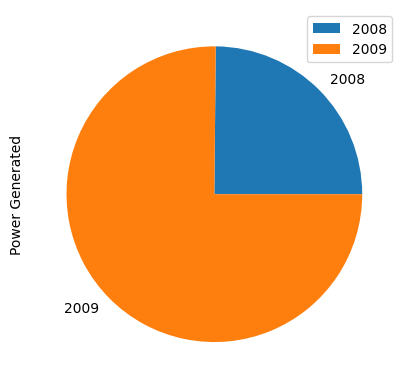

In [7]:
subdata = df.groupby('Year').sum()['Power Generated']
subdata.plot(kind='pie',legend = True, subplots=True)

<Axes: >

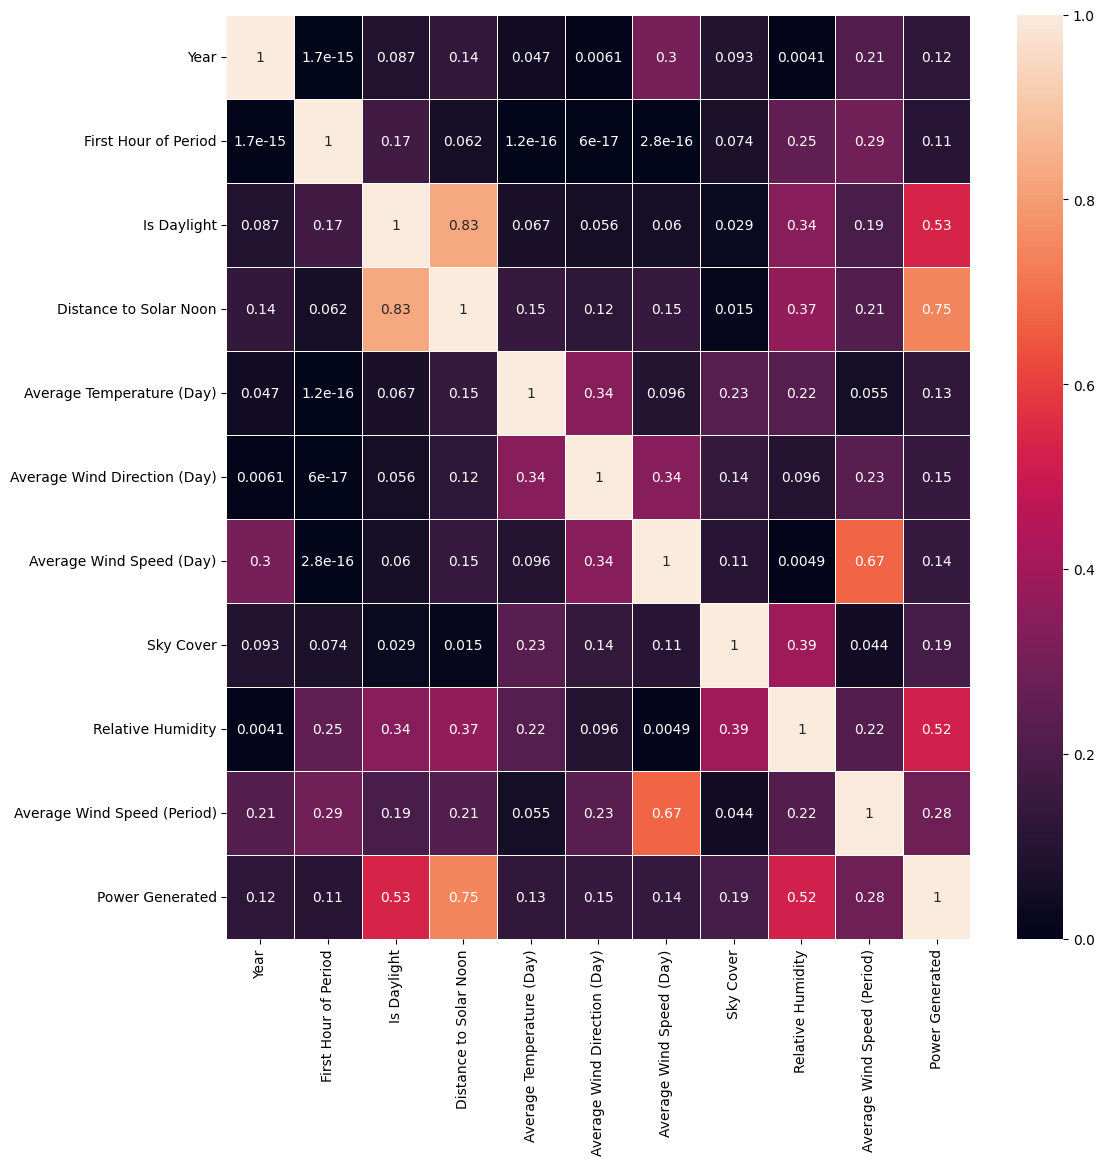

In [8]:
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(df.corr().abs(), annot=True, linewidths=.5, ax=ax)

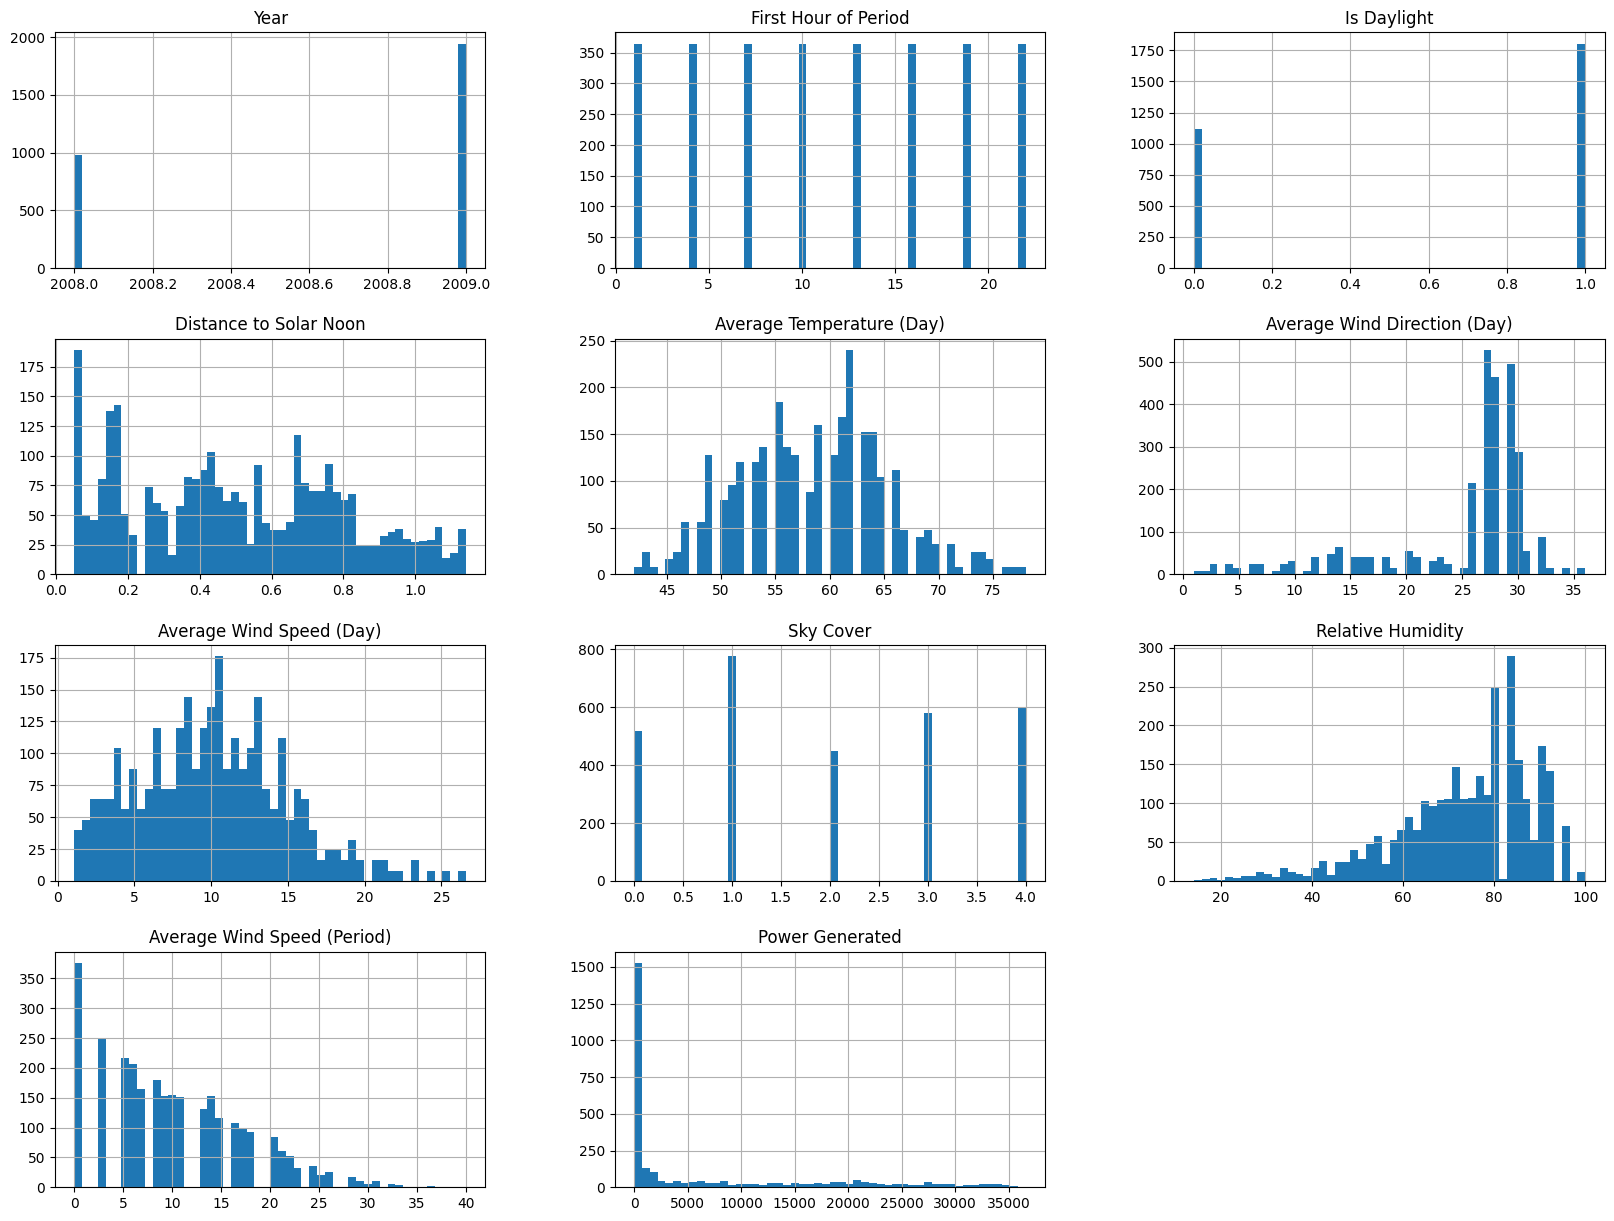

In [9]:
df.hist(bins=50,figsize=(20,15)) 
plt.show()

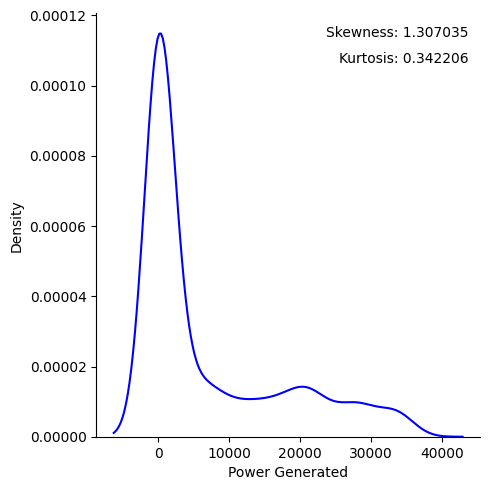

In [10]:
graph = sns.displot(data=df, x="Power Generated",kind ='kde',color='blue')
for ax in graph.axes.ravel():
    ax.text(x=0.97, y=0.97, transform=ax.transAxes, s="Skewness: %f" % df['Power Generated'].skew(),\
        fontsize=10, verticalalignment='top', horizontalalignment='right')
    ax.text(x=0.97, y=0.91, transform=ax.transAxes, s="Kurtosis: %f" % df['Power Generated'].kurt(),\
        fontsize=10, verticalalignment='top', horizontalalignment='right')

Text(0, 0.5, 'Frequency')

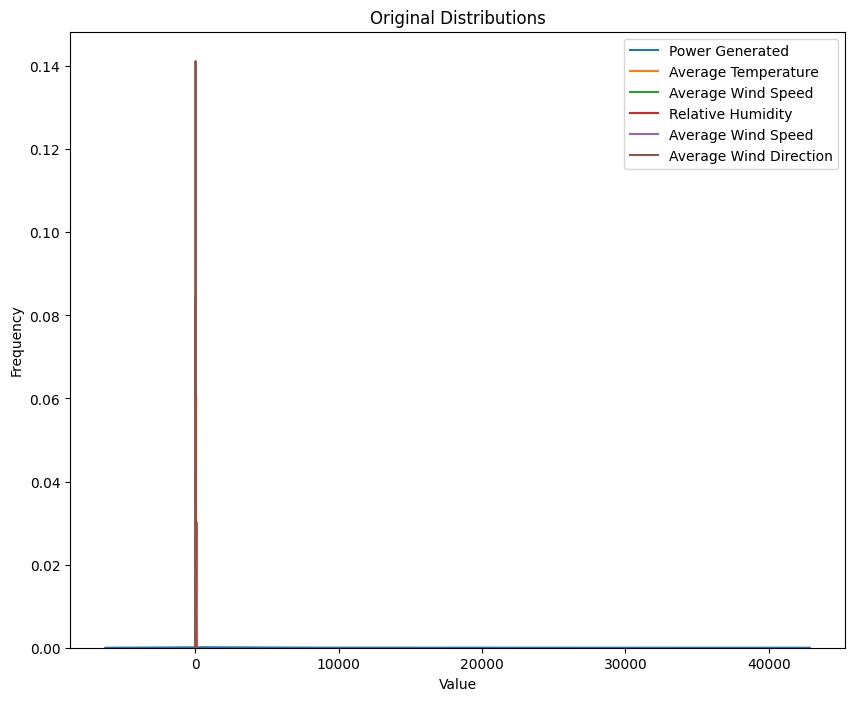

In [11]:
fig, (ax1) = plt.subplots(ncols=1, figsize=(10,8))
ax1.set_title('Original Distributions')

sns.kdeplot(df['Power Generated'], ax=ax1, label='Power Generated')
sns.kdeplot(df['Average Temperature (Day)'], ax=ax1, label='Average Temperature')
sns.kdeplot(df['Average Wind Speed (Day)'], ax=ax1, label='Average Wind Speed')
sns.kdeplot(df['Relative Humidity'], ax=ax1, label='Relative Humidity')
sns.kdeplot(df['Average Wind Speed (Period)'], ax=ax1, label='Average Wind Speed')
sns.kdeplot(df['Average Wind Direction (Day)'], ax=ax1, label='Average Wind Direction')

ax1.legend()
ax1.set_xlabel ('Value')
ax1.set_ylabel ('Frequency')

Text(0, 0.5, 'Frequency')

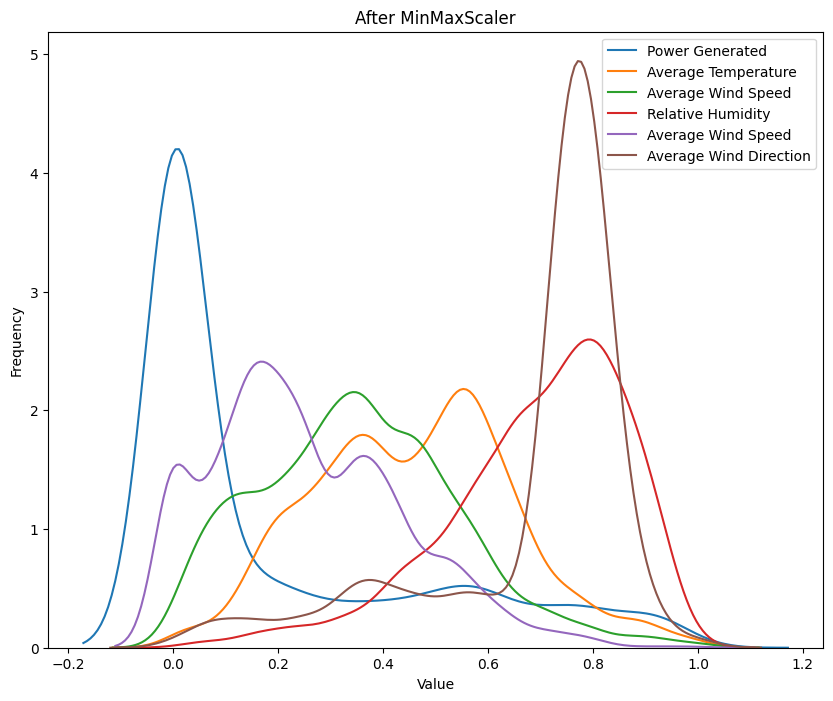

In [12]:
scaler = preprocessing.MinMaxScaler()

df[['Power Generated',
    'Average Temperature (Day)',
    'Average Wind Speed (Day)',
    'Relative Humidity',
    'Average Wind Speed (Period)',
    'Average Wind Direction (Day)'
   ]] = scaler.fit_transform(df[['Power Generated',
                                 'Average Temperature (Day)',
                                 'Average Wind Speed (Day)',
                                 'Relative Humidity',
                                 'Average Wind Speed (Period)',
                                 'Average Wind Direction (Day)'
                                ]])

fig, (ax1) = plt.subplots(ncols=1,figsize=(10, 8))
ax1.set_title('After MinMaxScaler')

sns.kdeplot(df['Power Generated'], ax=ax1, label='Power Generated')
sns.kdeplot(df['Average Temperature (Day)'], ax=ax1, label='Average Temperature')
sns.kdeplot(df['Average Wind Speed (Day)'], ax=ax1, label='Average Wind Speed')
sns.kdeplot(df['Relative Humidity'], ax=ax1, label='Relative Humidity')
sns.kdeplot(df['Average Wind Speed (Period)'], ax=ax1, label='Average Wind Speed')
sns.kdeplot(df['Average Wind Direction (Day)'], ax=ax1, label='Average Wind Direction')

ax1.legend()
ax1.set_xlabel ('Value')
ax1.set_ylabel ('Frequency')

In [13]:
df.head(10)

,Year,First Hour of Period,Is Daylight,Distance to Solar Noon,Average Temperature (Day),Average Wind Direction (Day),Average Wind Speed (Day),Sky Cover,Relative Humidity,Average Wind Speed (Period),Power Generated
0,2008,1,0,0.859897,0.750000,0.771429,0.250980,0,0.709302,0.200,0.000000
1,2008,4,0,0.628535,0.750000,0.771429,0.250980,0,0.732558,0.125,0.000000
2,2008,7,1,0.397172,0.750000,0.771429,0.250980,0,0.651163,0.000,0.148114
3,2008,10,1,0.165810,0.750000,0.771429,0.250980,0,0.220930,0.000,0.696473
4,2008,13,1,0.065553,0.750000,0.771429,0.250980,0,0.081395,0.075,0.822007
5,2008,16,1,0.296915,0.750000,0.771429,0.250980,0,0.069767,0.575,0.445052
6,2008,19,1,0.528278,0.750000,0.771429,0.250980,0,0.255814,0.375,0.014079
7,2008,22,0,0.759640,0.750000,0.771429,0.250980,0,0.406977,0.150,0.000000
8,2008,1,0,0.862113,0.833333,0.800000,0.223529,0,0.616279,0.150,0.000000
9,2008,4,0,0.630155,0.833333,0.800000,0.223529,0,0.406977,0.000,0.000000


3. Models and Hyperparametrization 

In [14]:
X = df.iloc[:,0:10]
y = df.iloc[:,10]

In [15]:
X.head(10)

,Year,First Hour of Period,Is Daylight,Distance to Solar Noon,Average Temperature (Day),Average Wind Direction (Day),Average Wind Speed (Day),Sky Cover,Relative Humidity,Average Wind Speed (Period)
0,2008,1,0,0.859897,0.750000,0.771429,0.250980,0,0.709302,0.200
1,2008,4,0,0.628535,0.750000,0.771429,0.250980,0,0.732558,0.125
2,2008,7,1,0.397172,0.750000,0.771429,0.250980,0,0.651163,0.000
3,2008,10,1,0.165810,0.750000,0.771429,0.250980,0,0.220930,0.000
4,2008,13,1,0.065553,0.750000,0.771429,0.250980,0,0.081395,0.075
5,2008,16,1,0.296915,0.750000,0.771429,0.250980,0,0.069767,0.575
6,2008,19,1,0.528278,0.750000,0.771429,0.250980,0,0.255814,0.375
7,2008,22,0,0.759640,0.750000,0.771429,0.250980,0,0.406977,0.150
8,2008,1,0,0.862113,0.833333,0.800000,0.223529,0,0.616279,0.150
9,2008,4,0,0.630155,0.833333,0.800000,0.223529,0,0.406977,0.000


In [16]:
y.head()

0    0.000000
1    0.000000
2    0.148114
3    0.696473
4    0.822007
Name: Power Generated, dtype: float64

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=0)

3.1 Testing k Factors

In [18]:
rmsle_val = []
best_rmsle = 1.0

for k in range(20):
    k = k+1
    knn = neighbors.KNeighborsRegressor(n_neighbors = k)

    knn.fit(X_train, y_train) 
    y_pred = knn.predict(X_test)
    rmsle = np.sqrt(mean_squared_log_error(y_test,y_pred))
    if (rmsle < best_rmsle):
        best_rmsle = rmsle
        best_k = k
    rmsle_val.append(rmsle)
    print('RMSLE value for k= ' , k , 'is:', rmsle)

print(f"Best RMSLE: {best_rmsle}, Best k: {best_k}")

RMSLE value for k=  1 is: 0.0813361167686482
RMSLE value for k=  2 is: 0.07130316047922348
RMSLE value for k=  3 is: 0.06837183342916907
RMSLE value for k=  4 is: 0.06551849259051497
RMSLE value for k=  5 is: 0.06412345125293233
RMSLE value for k=  6 is: 0.06363433222150022
RMSLE value for k=  7 is: 0.06370953687416882
RMSLE value for k=  8 is: 0.06398343487485723
RMSLE value for k=  9 is: 0.06482768093538513
RMSLE value for k=  10 is: 0.0661731366053233
RMSLE value for k=  11 is: 0.06699549942404986
RMSLE value for k=  12 is: 0.06794067717339873
RMSLE value for k=  13 is: 0.0680140303722776
RMSLE value for k=  14 is: 0.0683040989037495
RMSLE value for k=  15 is: 0.06872935501242321
RMSLE value for k=  16 is: 0.06904278389624127
RMSLE value for k=  17 is: 0.0692277968889119
RMSLE value for k=  18 is: 0.06956428683544388
RMSLE value for k=  19 is: 0.06975546396444686
RMSLE value for k=  20 is: 0.07013139639221679
Best RMSLE: 0.06363433222150022, Best k: 6


<Axes: >

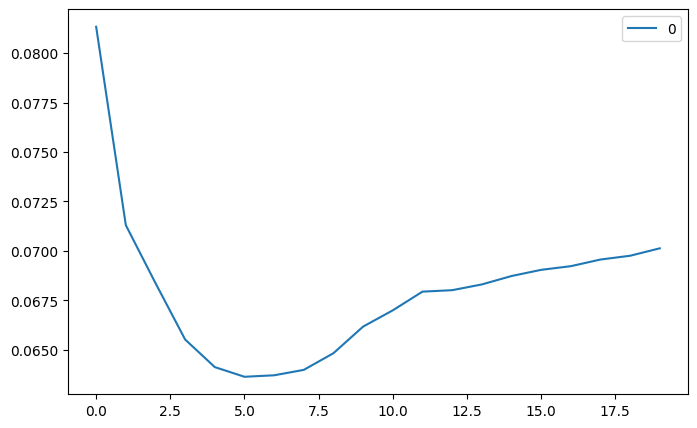

In [19]:
curve = pd.DataFrame(rmsle_val)
curve.plot(figsize=(8,5))

3.2 Tuning Hyperparameters 

In [20]:
params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11]}

knn = neighbors.KNeighborsRegressor()

model = GridSearchCV(knn, params)
model.fit(X_train,y_train)
model.best_params_

{'n_neighbors': 5}

3.3 Models

3.3.1 K-Nearest Neighbor

In [21]:
knn = neighbors.KNeighborsRegressor(n_neighbors = 6)

knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)
knn.score(X_test, y_test)

0.9055826293772716

3.3.2 Random Forest

In [22]:
forest_model = RandomForestRegressor(random_state=1)
forest_model.fit(X_train, y_train)
y_pred_rf = forest_model.predict(X_test)
forest_model.score(X_test, y_test)

0.9204095053307441

3.3.3 Ensemble Stacking

In [23]:
estimators=[("knn", knn), ("rf", forest_model)]
ensemble_stack = StackingRegressor(estimators=estimators)
ensemble_stack.fit(X_train, y_train)

y_pred_stacking = ensemble_stack.predict(X_test)
ensemble_stack.score(X_test, y_test)

0.9235130563642142

4 Anomaly Detection

In [24]:
#Creating a result table to compare the actual and predicted values of the target variable 
import pandas as pd

results = pd.DataFrame()

results["Actual_Power"] = y_test.values
results["Predicted_Power"] = y_pred_rf

results.head(10)

,Actual_Power,Predicted_Power
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.012438,0.012835
5,0.098989,0.089742
6,0.000000,0.000000
7,0.366238,0.407921
8,0.062165,0.308144
9,0.000000,0.000000


In [25]:
results["Error"] = abs(results["Actual_Power"] - results["Predicted_Power"])

results.head(10)

,Actual_Power,Predicted_Power,Error
0,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000
4,0.012438,0.012835,0.000397
5,0.098989,0.089742,0.009247
6,0.000000,0.000000,0.000000
7,0.366238,0.407921,0.041683
8,0.062165,0.308144,0.245978
9,0.000000,0.000000,0.000000


In [26]:
threshold = results["Error"].mean() + 2 * results["Error"].std()

print("Threshold:", threshold)

Threshold: 0.17786445806187834


In [27]:
results["Anomaly"] = results["Error"] > threshold

results.head(20)

,Actual_Power,Predicted_Power,Error,Anomaly
0,0.000000,0.000000,0.000000,False
1,0.000000,0.000000,0.000000,False
2,0.000000,0.000000,0.000000,False
3,0.000000,0.000000,0.000000,False
4,0.012438,0.012835,0.000397,False
5,0.098989,0.089742,0.009247,False
6,0.000000,0.000000,0.000000,False
7,0.366238,0.407921,0.041683,False
8,0.062165,0.308144,0.245978,True
9,0.000000,0.000000,0.000000,False


In [28]:
results["Anomaly"].value_counts()

Anomaly
False    831
True      45
Name: count, dtype: int64

In [ ]:
results["Error_Percent"] = np.where(
    results["Actual_Power"] == 0,
    0,
    (results["Error"] / results["Actual_Power"]) * 100
)

In [30]:
def anomaly_type(row):

    if row["Actual_Power"] == 0:
        return "Night / No Generation"

    elif row["Error_Percent"] < 10:
        return "Normal"

    elif row["Error_Percent"] < 25:
        return "Weather Variation"

    else:
        return "Possible Hardware Fault"

results["Anomaly_Type"] = results.apply(anomaly_type, axis=1)

In [31]:
results.head(20)

,Actual_Power,Predicted_Power,Error,Anomaly,Error_Percent,Anomaly_Type
0,0.000000,0.000000,0.000000,False,0.000000,Night / No Generation
1,0.000000,0.000000,0.000000,False,0.000000,Night / No Generation
2,0.000000,0.000000,0.000000,False,0.000000,Night / No Generation
3,0.000000,0.000000,0.000000,False,0.000000,Night / No Generation
4,0.012438,0.012835,0.000397,False,3.191209,Normal
5,0.098989,0.089742,0.009247,False,9.341342,Normal
6,0.000000,0.000000,0.000000,False,0.000000,Night / No Generation
7,0.366238,0.407921,0.041683,False,11.381354,Weather Variation
8,0.062165,0.308144,0.245978,True,395.685576,Possible Hardware Fault
9,0.000000,0.000000,0.000000,False,0.000000,Night / No Generation
